In [28]:
from spacerocks import SpaceRock
from spacerocks.time import Time
from spacerocks.observing import Observatory, Observation
from spacerocks.spice import SpiceKernel
from spacerocks.nbody import Simulation, Force
from spacerocks.orbfit import gauss, fit_orbit_lm, orbit_chisq
import numpy as np


import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

kernel = SpiceKernel()
kernel.load("/Users/kjnapier/data/spice/latest_leapseconds.tls")
kernel.load("/Users/kjnapier/data/spice/sb441-n16.bsp")
kernel.load("/Users/kjnapier/data/spice/de441_part-1.bsp")
kernel.load("/Users/kjnapier/data/spice/de441_part-2.bsp")
kernel.load("/Users/kjnapier/data/spice/earth_1962_240827_2124_combined.bpc")

Loading kernel: /Users/kjnapier/data/spice/latest_leapseconds.tls
Loading kernel: /Users/kjnapier/data/spice/sb441-n16.bsp
Loading kernel: /Users/kjnapier/data/spice/de441_part-1.bsp
Loading kernel: /Users/kjnapier/data/spice/de441_part-2.bsp
Loading kernel: /Users/kjnapier/data/spice/earth_1962_240827_2124_combined.bpc


In [29]:
kernel = SpiceKernel.defaults()


Using default configuration:
  Kernel paths: ["/Users/kjnapier/.spacerocks/spice"]
  Download directory: "/Users/kjnapier/.spacerocks/spice"
  Auto-download: true

Processing kernel: latest_leapseconds.tls
✓ Found existing kernel at: /Users/kjnapier/.spacerocks/spice/latest_leapseconds.tls
Loading kernel: /Users/kjnapier/.spacerocks/spice/latest_leapseconds.tls

Processing kernel: de440s.bsp
✓ Found existing kernel at: /Users/kjnapier/.spacerocks/spice/de440s.bsp
Loading kernel: /Users/kjnapier/.spacerocks/spice/de440s.bsp

Processing kernel: earth_1962_240827_2124_combined.bpc
➜ Downloading kernel...
    Saving to /Users/kjnapier/.spacerocks/spice/earth_1962_240827_2124_combined.bpc
Loading kernel: /Users/kjnapier/.spacerocks/spice/earth_1962_240827_2124_combined.bpc

Processing kernel: codes_300ast_20100725.bsp
✓ Found existing kernel at: /Users/kjnapier/.spacerocks/spice/codes_300ast_20100725.bsp
Loading kernel: /Users/kjnapier/.spacerocks/spice/codes_300ast_20100725.bsp

Processin

In [30]:
w84 = Observatory.from_obscode('w84')

In [31]:
from spacerocks import MPCHandler
handler = MPCHandler()

In [ ]:
handler.get_detections("2015 BP519", formats=["ADES_DF"])

In [4]:
epoch = Time.now()

name = "holman"
rock = SpaceRock.from_horizons(name, epoch=epoch, origin="ssb", reference_plane="J2000")
sim = Simulation.giants(epoch, "J2000", "ssb")
sim.add_force(Force.solar_gr())
sim.add_force(Force.solar_j2())

sim.add(rock)

In [5]:
e_truth = rock.e()

In [6]:
observations = []    
for idx in np.linspace(0, 300, 100):
    sim.integrate(epoch + idx)
    observer = w84.at(epoch + idx, reference_plane="J2000", origin="ssb")
    rock = sim.get_particle(name)
    obs = rock.observe(observer)
    observations.append(obs)

In [7]:
smear = 0.1/3600 * (np.pi / 180)

In [8]:
simulated_observations = []
for obs in observations:
    ra = obs.ra
    dec = obs.dec
    ra += np.random.normal(0, smear)
    dec += np.random.normal(0, smear)
    epoch = obs.epoch
    observer = obs.observer
    cov = [[smear**2, 0], [0, smear**2]]
    simulated_o = Observation.from_astrometry(obs.epoch, ra, dec, obs.observer)
    simulated_o.set_covariance(cov)
    simulated_observations.append(simulated_o)

In [9]:
import itertools

In [10]:
len(simulated_observations)

# generate all possible triplets of observations
triplets = list(itertools.combinations(simulated_observations, 3))
np.random.shuffle(triplets)

In [11]:
len(triplets)

161700

In [ ]:
for triplet in triplets[:1000]:
    rocks = gauss(triplet[0], triplet[1], triplet[2], min_distance=0.0001)

Time to solve: 12.083µs
Time to solve: 10.5µs
Time to solve: 9.625µs
Time to solve: 10.041µs
Time to solve: 9.583µs
Time to solve: 8.25µs
Time to solve: 10.042µs
Time to solve: 8.875µs
Time to solve: 9.916µs
Time to solve: 8.375µs
Time to solve: 11.666µs
Time to solve: 9.667µs
Time to solve: 9.5µs
Time to solve: 8.417µs
Time to solve: 8.166µs
Time to solve: 10.042µs
Time to solve: 9.375µs
Time to solve: 8.875µs
Time to solve: 8.459µs
Time to solve: 8.542µs
Time to solve: 8.417µs
Time to solve: 10.083µs
Time to solve: 9.542µs
Time to solve: 8.292µs
Time to solve: 7.708µs
Time to solve: 9.417µs
Time to solve: 10.042µs
Time to solve: 9.459µs
Time to solve: 10.167µs
Time to solve: 8.959µs
Time to solve: 11.5µs
Time to solve: 8.75µs
Time to solve: 8.5µs
Time to solve: 10.084µs
Time to solve: 8.459µs
Time to solve: 11.375µs
Time to solve: 8.375µs
Time to solve: 8.375µs
Time to solve: 9.625µs
Time to solve: 8.25µs
Time to solve: 8.334µs
Time to solve: 23.125µs
Time to solve: 10.334µs
Time to 

In [15]:
1.07 / len(triplets)

6.617192331478046e-06

In [11]:
# %%time
eccentricities = []
dts = []
ratios = []
for triplet in triplets:
    rocks = gauss(triplet[0], triplet[1], triplet[2], min_distance=1.0)
    times = [obs.epoch.tdb().jd() for obs in triplet]
    # sort the times
    times.sort()
    dt1 = times[1] - times[0]
    dt2 = times[2] - times[1]
    dt = times[2] - times[0]
    if rocks is None:
        continue
    for rock in rocks:
        eccentricities.append(rock.e())
        dts.append(dt)
        ratio = min(dt1, dt2) / max(dt1, dt2)
        ratios.append(ratio)

eccentricities = np.array(eccentricities)
keep = eccentricities < 1.0
eccentricities = eccentricities[keep]
dts = np.array(dts)
dts = dts[keep]
ratios = np.array(ratios)
ratios = ratios[keep]


In [46]:
import pandas as pd

In [47]:
triplets = list(itertools.combinations(simulated_observations, 3))
# shuffle the triplets
np.random.shuffle(triplets)

In [49]:
for tdx, triplet in enumerate(triplets[:10]):

    rocks = gauss(triplet[0], triplet[1], triplet[2], min_distance=0.0001)

    ras = []
    decs = []
    epochs = []
    oxs = []
    oys = []
    ozs = []
    ovxs = []
    ovys = []
    ovzs = []
    for idx in range(3):
        ra = triplet[idx].ra
        dec = triplet[idx].dec
        epoch = triplet[idx].epoch.utc().jd()
        ox, oy, oz = triplet[idx].observer.position
        ovx, ovy, ovz = triplet[idx].observer.velocity
        ras.append(ra)
        decs.append(dec)
        epochs.append(epoch)
        oxs.append(ox)
        oys.append(oy)
        ozs.append(oz)
        ovxs.append(ovx)
        ovys.append(ovy)
        ovzs.append(ovz)

    observation_dict = {
        "ra": ras,
        "dec": decs,
        "epoch": epochs,
        "ox": oxs,
        "oy": oys,
        "oz": ozs,
        "ovx": ovxs,
        "ovy": ovys,
        "ovz": ovzs
    }

    solution_xs = []
    solution_ys = []
    solution_zs = []
    solution_vxs = []
    solution_vys = []
    solution_vzs = []
    solution_epochs = []
    solution_origins = []
    for rock in rocks:
        solution_xs.append(rock.x)
        solution_ys.append(rock.y)
        solution_zs.append(rock.z)
        solution_vxs.append(rock.vx)
        solution_vys.append(rock.vy)
        solution_vzs.append(rock.vz)
        solution_epochs.append(rock.epoch.utc().jd())
        solution_origins.append(rock.origin)


    print(rock.e())

    solution_dict = {
        "x": solution_xs,
        "y": solution_ys,
        "z": solution_zs,
        "vx": solution_vxs,
        "vy": solution_vys,
        "vz": solution_vzs,
        "epoch": solution_epochs,
        "origin": solution_origins
    }

    # solution_df = pd.DataFrame(solution_dict)
    # observation_df = pd.DataFrame(observation_dict)
    # solution_df.to_csv(f"/Users/kjnapier/Desktop/test_data/solutions_{tdx}.csv")
    # observation_df.to_csv(f"/Users/kjnapier/Desktop/test_data/observations_{tdx}.csv")

0.13216079079421134
0.7911521466507159
0.9969373998777316
0.12933759609934228
0.13388794499190673
0.13152593077597882
0.13191167474066862
0.9894506083685937
0.8720329401251856
0.13129855559772452


In [43]:
rocks

[SpaceRock: rock
 position: [[3.2986563796527575, 0.513561817807007, 0.08354202231878394]]
 velocity: [[-0.0007368825968175895, 0.007168313796374479, 0.002921314165691416]]
 epoch: 2461042.2533519175 TDB JD
 reference_plane: J2000
 origin: SSB,
 SpaceRock: rock
 position: [[0.6546693531229251, 0.7915914715492558, 0.3095498115002604]]
 velocity: [[-0.013415074140949803, -0.0005662192683691559, -0.0002815933057414344]]
 epoch: 2461042.266442587 TDB JD
 reference_plane: J2000
 origin: SSB,
 SpaceRock: rock
 position: [[-0.19620351585608942, 0.8810653936098336, 0.3822823529472739]]
 velocity: [[-0.0174912775623293, -0.003052970988183114, -0.0013113692023444521]]
 epoch: 2461042.2669773977 TDB JD
 reference_plane: J2000
 origin: SSB]

In [41]:
rocks

[SpaceRock: rock
 position: [[3.2986563796527575, 0.513561817807007, 0.08354202231878394]]
 velocity: [[-0.0007368825968175895, 0.007168313796374479, 0.002921314165691416]]
 epoch: 2461042.2533519175 TDB JD
 reference_plane: J2000
 origin: SSB,
 SpaceRock: rock
 position: [[0.6546693531229251, 0.7915914715492558, 0.3095498115002604]]
 velocity: [[-0.013415074140949803, -0.0005662192683691559, -0.0002815933057414344]]
 epoch: 2461042.266442587 TDB JD
 reference_plane: J2000
 origin: SSB,
 SpaceRock: rock
 position: [[-0.19620351585608942, 0.8810653936098336, 0.3822823529472739]]
 velocity: [[-0.0174912775623293, -0.003052970988183114, -0.0013113692023444521]]
 epoch: 2461042.2669773977 TDB JD
 reference_plane: J2000
 origin: SSB]

In [39]:
ras

[6.168346134693709, 6.178414894120262, 6.188892051374318]

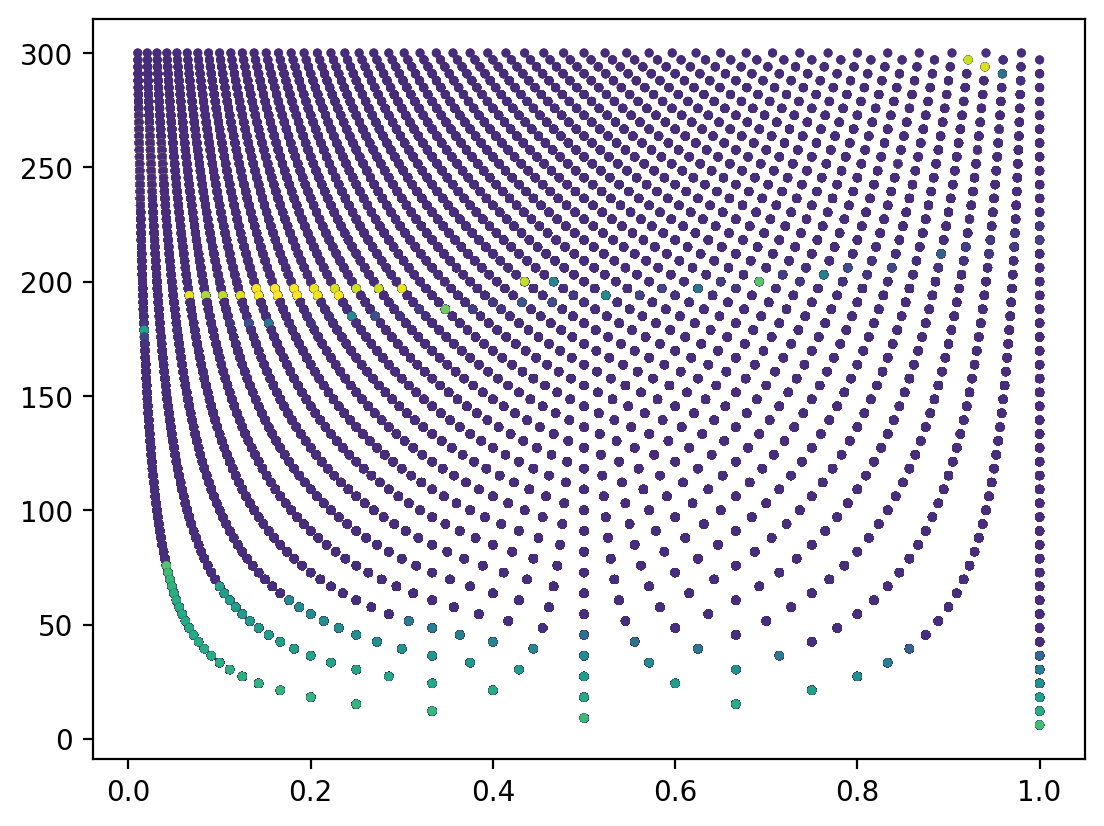

In [51]:
plt.scatter(ratios, dts, c=eccentricities, cmap='viridis', s=5)

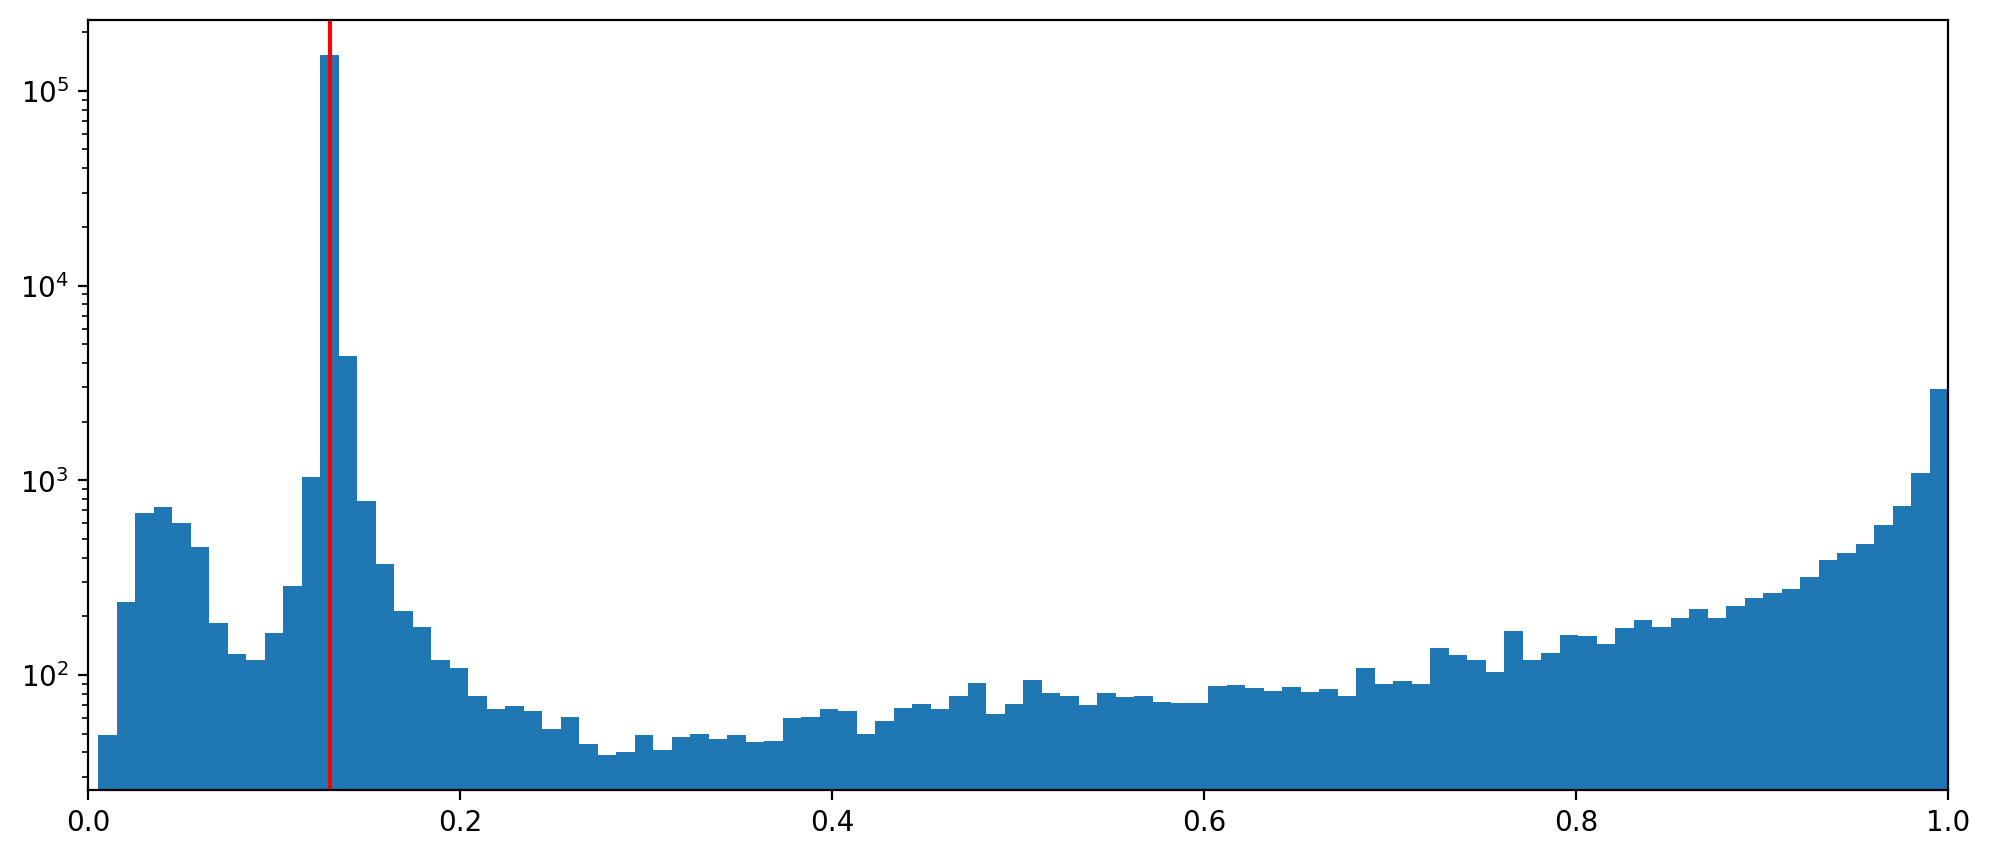

In [54]:
fig, ax = plt.subplots(figsize=(12, 5))
_ = ax.hist(eccentricities, bins=100)
ax.set_yscale('log')
ax.set_xlim([0, 1])
ax.axvline(e_truth, color='red')
#ax.set_xscale('log')

In [26]:
%%timeit
rocks = gauss(simulated_observations[0], simulated_observations[5], simulated_observations[9], min_distance=1e-6)


5.77 μs ± 73 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [25]:
sim = Simulation.giants(rocks[0].epoch, "J2000", "ssb")
x = fit_orbit_lm(simulated_observations, rocks[0], sim)

Parameters converged
Final chisq: 251.95495408879046
Final chisq/dof: 1.2987368767463425
Final parameters: [2.9527826017134955, -1.641693355486744, -0.7853433974689018, 0.004995740466376748, 0.0066526442877703216, 0.002528684179063472, 2460760.434281075]
Time elapsed in LM fit is: 884.887292ms


## Setting up our Orbit Fitting GUI

In [19]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [20]:
class OrbitFitAnalyzer:
    def __init__(self, observations, simulation, initial_guess = None):
        
        self.observations = observations
        self.simulation = simulation
        self.current_fit = None
        
        # Create widgets
        self.create_widgets()

        # Set initial guess
        if initial_guess is None:
            self.set_initial_guess()
        else:
            self.initial_guess = initial_guess
        
        # Initial fit
        self.refit_orbit()

        
    
    def create_widgets(self):
        # Setup the layout 
        COLUMN_WIDTHS = {
            'obs_num': '150px',      # For Observation Number column
            'gauss': '150px',        # For Initial Guess checkbox column
            'data': '300px'          # For observation data column
        }

        # Create checkboxes for each observation
        self.obs_checkboxes = []
        self.gauss_checkboxes = []
        obs_rows = []

        header_style = 'font-weight: bold; border-bottom: 1px solid #ccc; padding-bottom: 5px;'
        header = widgets.HBox([
            widgets.HTML(f'<div style="{header_style}; width: {COLUMN_WIDTHS["obs_num"]}">Observation Number</div>'),
            widgets.HTML(f'<div style="{header_style}; width: {COLUMN_WIDTHS["gauss"]}">Initial Guess (Gauss)</div>'),
            widgets.HTML(f'<div style="{header_style}; width: {COLUMN_WIDTHS["data"]}">Obs Data</div>')
        ])

        
        for i, obs in enumerate(self.observations):
            checkbox = widgets.Checkbox(
                value=True,
                description=f'Obs {i}',
                indent=False,
                layout=widgets.Layout(width=COLUMN_WIDTHS['obs_num'])
            )
            self.obs_checkboxes.append(checkbox)


            # Create checkboxes for initial guess
            checkbox_gauss = widgets.Checkbox(
                value=False,
                indent=False,
                layout=widgets.Layout(width=COLUMN_WIDTHS['gauss'])
            )

            self.gauss_checkboxes.append(checkbox_gauss)
            
            # Create info text
            info = widgets.HTML(
                f'''
                <div style="margin-left: 2px">
                    {obs.epoch.calendar()} | 
                    RA: {np.degrees(obs.ra):.2f}° | 
                    Dec: {np.degrees(obs.dec):.2f}°
                </div>
                ''', 
                layout=widgets.Layout(width=COLUMN_WIDTHS['data'])
            )
            
            obs_rows.append(widgets.HBox([checkbox, checkbox_gauss, info]))
        
        # Create refit button
        self.refit_button = widgets.Button(
            description='Refit Orbit',
            button_style='primary'
        )

        self.refit_button.on_click(self.on_refit_clicked)

        # Create button to select/deselect all observations
        self.select_all_button = widgets.Button(description='Select All')
        self.select_none_button = widgets.Button(description='Select None')
        
        self.select_all_button.on_click(lambda b: [setattr(cb, 'value', True) for cb in self.obs_checkboxes])
        self.select_none_button.on_click(lambda b: [setattr(cb, 'value', False) for cb in self.obs_checkboxes])

        
        # Output area for plots and results
        self.output = widgets.Output()
    

        # Layout everything
        self.main_box = widgets.VBox([
            widgets.HTML('<h3>Orbit Fit Analysis</h3>'),
            header,
            widgets.VBox(obs_rows),
            self.refit_button,
            widgets.HBox([self.select_all_button, self.select_none_button]),
            self.output
        ])

  
    @staticmethod
    def gauss_to_rock(gauss_obs):
        rocks = gauss(*gauss_obs, min_distance=1e-6)
        if rocks is None:
            print("Initial guess with selected observations failed!")
            return
        return rocks[0]
    
    def set_initial_guess(self):
        random_obs = np.random.choice(self.observations, 3, replace=False)
        # I need to mark the checkboxes for the initial guess with the selected observations
        for i, obs in enumerate(self.observations):
            gauss_checkbox = self.gauss_checkboxes[i]
            if obs in random_obs:
                gauss_checkbox.value = True
            else:
                gauss_checkbox.value = False

        self.initial_guess = OrbitFitAnalyzer.gauss_to_rock(random_obs)

   
    def on_refit_clicked(self, b):
        self.refit_orbit()
    
    def refit_orbit(self):
        print("Refitting orbit...") 

        selected_obs = [
            obs for obs, checkbox in zip(self.observations, self.obs_checkboxes)
            if checkbox.value
        ]

        try:
            # See if I need to regererate the initial guess based on checked boxes in the GUI
            if any([checkbox.value for checkbox in self.gauss_checkboxes]):
                selected_gauss_obs = [
                    obs for obs, checkbox in zip(self.observations, self.gauss_checkboxes)
                    if checkbox.value
                ]
                
                self.initial_guess = OrbitFitAnalyzer.gauss_to_rock(selected_gauss_obs)
                
            fit_result = fit_orbit_lm(selected_obs, self.initial_guess, self.simulation)
            #print(f"fit_orbit_lm returned: {fit_result}")  # Debugging output

            if fit_result is None:
                print("Error: fit_orbit_lm() returned None!")
                return  #
            
            self.current_fit = fit_result
            #print("Orbit fitting completed successfully.")  # Debugging print

            #print("Calling display_results()...")  # Debugging print
            self.display_results()  # Ensure this line is reached
        except Exception as e:
            print(f"Fit failed: {str(e)}")  

    
    def display_results(self):
        if self.current_fit is None:
            return
                
        with self.output:
            clear_output(wait=True)

            
            # Display fit statistics
            print(f"Fit Statistics:")
            chi2_per_dof = self.current_fit.chisq / self.current_fit.dof
            print(f"χ²/DOF: {chi2_per_dof:.2f}")
            print(f"χ²: {self.current_fit.chisq:.2f}")
            print(f"DOF: {self.current_fit.dof:.0f}")
            print(f"Iterations: {self.current_fit.niter}")
            
            # # Plot the residuals (from fitter.rs residuals function)
            plt.figure(figsize=(10, 6))
            residuals = self.current_fit.residuals
            
            
            plt.scatter(range(len(residuals)), residuals, label='Residuals')
            plt.xlabel('Observation Number')
            plt.ylabel('Residuals')
            plt.title('Fit Residuals')
            plt.legend()
            plt.grid(True)
            plt.minorticks_on()
            plt.show()

            
            # Get the fitted SpaceRock
            fitted_rock = self.current_fit.rock
            
            # cov = np.array(self.current_fit.covariance).reshape(6, 6)
            
            
            # # Get the uncertainties of our fitted parameters
            uncertainties = np.sqrt(np.diag(cov))
            
            elements = ['x', 'y', 'z', 'vx', 'vy', 'vz']
            values = [
                fitted_rock.x,
                fitted_rock.y,
                fitted_rock.z,
                fitted_rock.vx,
                fitted_rock.vy,
                fitted_rock.vz
                
            ]
            
            elements_df = pd.DataFrame({
                'Orbital Element': elements,
                'Value': [f"{v:.6f}" for v in values],
                'Uncertainty': [f"{u:.9f}" for u in uncertainties]
            })
            display(elements_df)

            kep_cov = np.array(self.current_fit.keplerian_covariance).reshape(6, 6)
            kep_uncertainties = np.sqrt(np.diag(kep_cov))

            kep_elements = ['a', 'e', 'i', 'ω', 'Ω', 'M0']
            kep_values = [
                fitted_rock.a(),
                fitted_rock.e(),
                fitted_rock.inc(),
                fitted_rock.arg(),
                fitted_rock.node(),
                fitted_rock.mean_anomaly()
            ]

            kep_elements_df = pd.DataFrame({
                'Orbital Element': kep_elements,
                'Value': [f"{v:.6f}" for v in kep_values],
                'Uncertainty': [f"{u:.9f}" for u in kep_uncertainties]
            })

            display(kep_elements_df)

            # Create single plot for residuals
            plt.figure(figsize=(10, 6))
            
            # Convert radians to arcseconds
            ra_residuals = np.array(self.current_fit.ra_residuals) * 206265
            dec_residuals = np.array(self.current_fit.dec_residuals) * 206265
            
            plt.scatter(range(len(ra_residuals)), ra_residuals, label='RA', alpha=0.7)
            plt.scatter(range(len(dec_residuals)), dec_residuals, label='Dec', alpha=0.7)
            
            plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)  
            plt.xlabel('Observation Number')
            plt.ylabel('Residuals (arcsec)')
            plt.title('Astrometric Residuals')
            plt.legend()
            plt.grid(True)
            plt.minorticks_on()
            
            plt.tight_layout()
            plt.show()

            # Or if we wanna plot residuals separately
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
            
            # Convert residuals to arcseconds for better readability
            ra_residuals = [np.degrees(r) * 3600 for r in self.current_fit.ra_residuals]  
            dec_residuals = [np.degrees(r) * 3600 for r in self.current_fit.dec_residuals]
            
            ax1.scatter(range(len(ra_residuals)), ra_residuals, label='RA Residuals')
            ax1.set_ylabel('RA Residuals (arcsec)')
            ax1.legend()
            ax1.grid(True)
            ax1.minorticks_on()
            
            ax2.scatter(range(len(dec_residuals)), dec_residuals, label='Dec Residuals')
            ax2.set_xlabel('Observation Number')
            ax2.set_ylabel('Dec Residuals (arcsec)')
            ax2.legend()
            ax2.grid(True)
            ax2.minorticks_on()
            
            plt.tight_layout()
            plt.show()

    
    def display(self):
        display(self.main_box)

    

In [21]:
#analyzer = OrbitFitAnalyzer(simulated_observations, rocks[0], sim)
analyzer = OrbitFitAnalyzer(simulated_observations, sim) # Calling without initial guess will generate a random initial guess using 3 observations and gauss' method
analyzer.display()

Refitting orbit...
Iteration: 0, chisq: 611318.1682759107, lambda: 0.001, ndof: 54
Error: fit_orbit_lm() returned None!
Iteration: 1, chisq: 157475.74440101624, lambda: 0.0001, ndof: 54
Iteration: 2, chisq: 39595.752724586346, lambda: 0.00001, ndof: 54
Iteration: 3, chisq: 9982.583534166097, lambda: 0.0000010000000000000002, ndof: 54
Iteration: 4, chisq: 2532.3358838997024, lambda: 0.00000010000000000000002, ndof: 54
Iteration: 5, chisq: 654.4013294841108, lambda: 0.000000010000000000000004, ndof: 54
Iteration: 6, chisq: 184.2621677727701, lambda: 0.0000000010000000000000005, ndof: 54
Iteration: 7, chisq: 76.86426836451147, lambda: 0.00000000010000000000000006, ndof: 54
Iteration: 8, chisq: 63.685460378319725, lambda: 0.000000000010000000000000006, ndof: 54
Iteration: 9, chisq: 63.685460378319725, lambda: 0.00000000010000000000000006, ndof: 54
Iteration: 10, chisq: 63.685460378319725, lambda: 0.0000000010000000000000005, ndof: 54
Iteration: 11, chisq: 63.685460378319725, lambda: 0.0000

In [20]:
# You can modify the simulation in this way, or use a whole new simulation 
# Just hit the refit button after you've made your changes
analyzer.simulation.remove("jupiter barycenter")

In [21]:
jupiter_barcyenter = SpaceRock.from_spice("jupiter barycenter", epoch=sim.epoch, origin="ssb", reference_plane="J2000")
analyzer.simulation.add(jupiter_barcyenter)